### References:

Diffusion models from scratch in python: https://www.youtube.com/watch?v=a4Yfz2FxXiY

Actual DDPM paper and its github: https://arxiv.org/pdf/2006.11239 | https://github.com/hojonathanho/diffusion

Deepseek - V3

Prompts:

I have images from different sources in respective directories under one directory, 
how can i use that dataset so that i can further process it into my diffusion model.

Can you implement mixed precision training and gradient scaling in the training loop

In [1]:
import os
import glob
import torch
import torchvision
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset

In [2]:
image_path = "../data/images/stickers"

diffusion_config = {"num_timesteps":1000, "beta_start":0.0001, "beta_end":0.02}
    
model_config = {
    "im_channels": 3,
    "im_size": 64,
    "down_channels": [16, 32, 64, 128], 
    "mid_channels": [128, 64],  
    "down_sample": [True, True, False],
    "time_emb_dim": 128,
    "num_down_layers": 1,  # Reduced layers
    "num_mid_layers": 1,  # Reduced layers
    "num_up_layers": 1,  # Reduced layers
    "num_heads": 4
}
    
train_config = {"batch_size":16, 
                "num_epochs": 50, 
                "num_samples": 100, 
                "num_grid_rows": 10,
                "task_name": 'default', 
                "ckpt_name":'ddpm_cpkt.pth'}

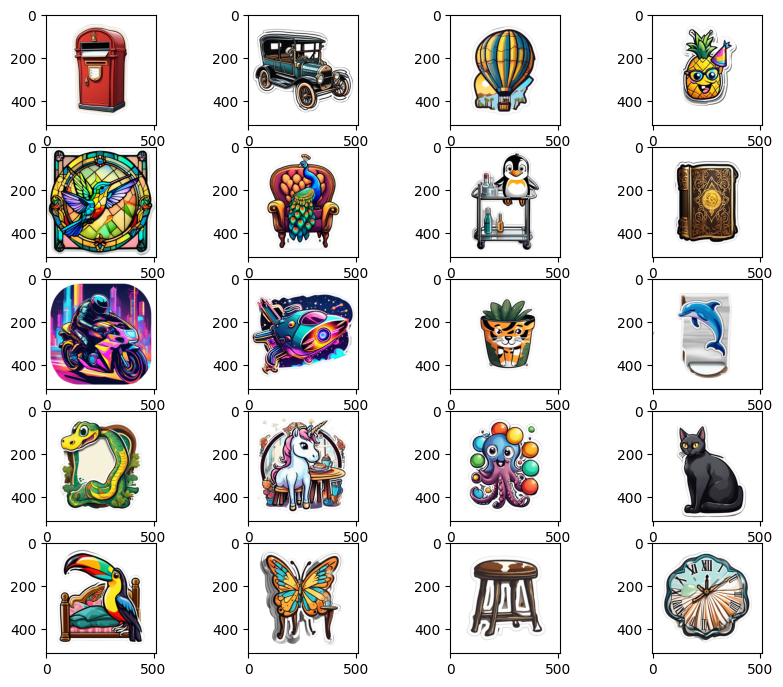

In [3]:
def show_images(datset, num_samples=20, cols=4):
    """ Plots some samples from the dataset """
    plt.figure(figsize=(10,10)) 
    for i, img in enumerate(data):
        if i == num_samples:
            break
        plt.subplot(int(num_samples/cols) + 1, cols, i + 1)
        plt.imshow(img[0])

data = datasets.ImageFolder(root=image_path)
show_images(data)

In [4]:
# Class for the linear noise scheduler that is used in DDPM.
class LinearNoiseScheduler:
    def __init__(self, num_timesteps, beta_start, beta_end):
        self.num_timesteps = num_timesteps
        self.beta_start = beta_start
        self.beta_end = beta_end
        
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps)
        self.alphas = 1. - self.betas
        self.alpha_cum_prod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_cum_prod = torch.sqrt(self.alpha_cum_prod)
        self.sqrt_one_minus_alpha_cum_prod = torch.sqrt(1 - self.alpha_cum_prod)
        
    def add_noise(self, original, noise, t):
        r"""
        Forward method for diffusion
        :param original: Image on which noise is to be applied
        :param noise: Random Noise Tensor (from normal dist)
        :param t: timestep of the forward process of shape -> (B,)
        :return:
        """
        original_shape = original.shape
        batch_size = original_shape[0]
        
        sqrt_alpha_cum_prod = self.sqrt_alpha_cum_prod.to(original.device)[t].reshape(batch_size)
        sqrt_one_minus_alpha_cum_prod = self.sqrt_one_minus_alpha_cum_prod.to(original.device)[t].reshape(batch_size)
        
        # Reshape till (B,) becomes (B,1,1,1) if image is (B,C,H,W)
        for _ in range(len(original_shape) - 1):
            sqrt_alpha_cum_prod = sqrt_alpha_cum_prod.unsqueeze(-1)
        for _ in range(len(original_shape) - 1):
            sqrt_one_minus_alpha_cum_prod = sqrt_one_minus_alpha_cum_prod.unsqueeze(-1)
        
        # Apply and Return Forward process equation
        return (sqrt_alpha_cum_prod.to(original.device) * original
                + sqrt_one_minus_alpha_cum_prod.to(original.device) * noise)
        
    def sample_prev_timestep(self, xt, noise_pred, t):
        r"""
            Use the noise prediction by model to get
            xt-1 using xt and the noise predicted
        :param xt: current timestep sample
        :param noise_pred: model noise prediction
        :param t: current timestep we are at
        :return:
        """
        x0 = ((xt - (self.sqrt_one_minus_alpha_cum_prod.to(xt.device)[t] * noise_pred)) /
              torch.sqrt(self.alpha_cum_prod.to(xt.device)[t]))
        x0 = torch.clamp(x0, -1., 1.)
        
        mean = xt - ((self.betas.to(xt.device)[t]) * noise_pred) / (self.sqrt_one_minus_alpha_cum_prod.to(xt.device)[t])
        mean = mean / torch.sqrt(self.alphas.to(xt.device)[t])
        
        if t == 0:
            return mean, x0
        else:
            variance = (1 - self.alpha_cum_prod.to(xt.device)[t - 1]) / (1.0 - self.alpha_cum_prod.to(xt.device)[t])
            variance = variance * self.betas.to(xt.device)[t]
            sigma = variance ** 0.5
            z = torch.randn(xt.shape).to(xt.device)
            
            # OR
            # variance = self.betas[t]
            # sigma = variance ** 0.5
            # z = torch.randn(xt.shape).to(xt.device)
            return mean + sigma * z, x0

In [5]:
def get_time_embedding(time_steps, temb_dim):
    """
    Convert time steps tensor into an embedding using the
    sinusoidal time embedding formula
    :param time_steps: 1D tensor of length batch size
    :param temb_dim: Dimension of the embedding
    :return: BxD embedding representation of B time steps
    """
    assert temb_dim % 2 == 0, "time embedding dimension must be divisible by 2"
    
    # factor = 10000^(2i/d_model)
    factor = 10000 ** ((torch.arange(
        start=0, end=temb_dim // 2, dtype=torch.float32, device=time_steps.device) / (temb_dim // 2))
    )
    
    # pos / factor
    # timesteps B -> B, 1 -> B, temb_dim
    t_emb = time_steps[:, None].repeat(1, temb_dim // 2) / factor
    t_emb = torch.cat([torch.sin(t_emb), torch.cos(t_emb)], dim=-1)
    return t_emb


class DownBlock(nn.Module):
    r"""
    Down conv block with attention.
    Sequence of following block
    1. Resnet block with time embedding
    2. Attention block
    3. Downsample using 2x2 average pooling
    """
    def __init__(self, in_channels, out_channels, t_emb_dim,
                 down_sample=True, num_heads=4, num_layers=1):
        super().__init__()
        self.num_layers = num_layers
        self.down_sample = down_sample
        self.resnet_conv_first = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(8, in_channels if i == 0 else out_channels),
                    nn.SiLU(),
                    nn.Conv2d(in_channels if i == 0 else out_channels, out_channels,
                              kernel_size=3, stride=1, padding=1),
                )
                for i in range(num_layers)
            ]
        )
        self.t_emb_layers = nn.ModuleList([
            nn.Sequential(
                nn.SiLU(),
                nn.Linear(t_emb_dim, out_channels)
            )
            for _ in range(num_layers)
        ])
        self.resnet_conv_second = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(8, out_channels),
                    nn.SiLU(),
                    nn.Conv2d(out_channels, out_channels,
                              kernel_size=3, stride=1, padding=1),
                )
                for _ in range(num_layers)
            ]
        )
        self.attention_norms = nn.ModuleList(
            [nn.GroupNorm(8, out_channels)
             for _ in range(num_layers)]
        )
        
        self.attentions = nn.ModuleList(
            [nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
             for _ in range(num_layers)]
        )
        self.residual_input_conv = nn.ModuleList(
            [
                nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1)
                for i in range(num_layers)
            ]
        )
        self.down_sample_conv = nn.Conv2d(out_channels, out_channels,
                                          4, 2, 1) if self.down_sample else nn.Identity()
    
    def forward(self, x, t_emb):
        out = x
        for i in range(self.num_layers):
            
            # Resnet block of Unet
            resnet_input = out
            out = self.resnet_conv_first[i](out)
            out = out + self.t_emb_layers[i](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i](out)
            out = out + self.residual_input_conv[i](resnet_input)
            
            # Attention block of Unet
            batch_size, channels, h, w = out.shape
            in_attn = out.reshape(batch_size, channels, h * w)
            in_attn = self.attention_norms[i](in_attn)
            in_attn = in_attn.transpose(1, 2)
            out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
            out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
            out = out + out_attn
            
        out = self.down_sample_conv(out)
        return out


class MidBlock(nn.Module):
    r"""
    Mid conv block with attention.
    Sequence of following blocks
    1. Resnet block with time embedding
    2. Attention block
    3. Resnet block with time embedding
    """
    def __init__(self, in_channels, out_channels, t_emb_dim, num_heads=4, num_layers=1):
        super().__init__()
        self.num_layers = num_layers
        self.resnet_conv_first = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(8, in_channels if i == 0 else out_channels),
                    nn.SiLU(),
                    nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=3, stride=1,
                              padding=1),
                )
                for i in range(num_layers+1)
            ]
        )
        self.t_emb_layers = nn.ModuleList([
            nn.Sequential(
                nn.SiLU(),
                nn.Linear(t_emb_dim, out_channels)
            )
            for _ in range(num_layers + 1)
        ])
        self.resnet_conv_second = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(8, out_channels),
                    nn.SiLU(),
                    nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
                )
                for _ in range(num_layers+1)
            ]
        )
        
        self.attention_norms = nn.ModuleList(
            [nn.GroupNorm(8, out_channels)
                for _ in range(num_layers)]
        )
        
        self.attentions = nn.ModuleList(
            [nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
                for _ in range(num_layers)]
        )
        self.residual_input_conv = nn.ModuleList(
            [
                nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1)
                for i in range(num_layers+1)
            ]
        )
    
    def forward(self, x, t_emb):
        out = x
        
        # First resnet block
        resnet_input = out
        out = self.resnet_conv_first[0](out)
        out = out + self.t_emb_layers[0](t_emb)[:, :, None, None]
        out = self.resnet_conv_second[0](out)
        out = out + self.residual_input_conv[0](resnet_input)
        
        for i in range(self.num_layers):
            
            # Attention Block
            batch_size, channels, h, w = out.shape
            in_attn = out.reshape(batch_size, channels, h * w)
            in_attn = self.attention_norms[i](in_attn)
            in_attn = in_attn.transpose(1, 2)
            out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
            out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
            out = out + out_attn
            
            # Resnet Block
            resnet_input = out
            out = self.resnet_conv_first[i+1](out)
            out = out + self.t_emb_layers[i+1](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i+1](out)
            out = out + self.residual_input_conv[i+1](resnet_input)
        
        return out


class UpBlock(nn.Module):
    r"""
    Up conv block with attention.
    Sequence of following blocks
    1. Upsample
    1. Concatenate Down block output
    2. Resnet block with time embedding
    3. Attention Block
    """
    def __init__(self, in_channels, out_channels, t_emb_dim, up_sample=True, num_heads=4, num_layers=1):
        super().__init__()
        self.num_layers = num_layers
        self.up_sample = up_sample
        self.resnet_conv_first = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(8, in_channels if i == 0 else out_channels),
                    nn.SiLU(),
                    nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=3, stride=1,
                              padding=1),
                )
                for i in range(num_layers)
            ]
        )
        self.t_emb_layers = nn.ModuleList([
            nn.Sequential(
                nn.SiLU(),
                nn.Linear(t_emb_dim, out_channels)
            )
            for _ in range(num_layers)
        ])
        self.resnet_conv_second = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(8, out_channels),
                    nn.SiLU(),
                    nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
                )
                for _ in range(num_layers)
            ]
        )
        
        self.attention_norms = nn.ModuleList(
            [
                nn.GroupNorm(8, out_channels)
                for _ in range(num_layers)
            ]
        )
        
        self.attentions = nn.ModuleList(
            [
                nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
                for _ in range(num_layers)
            ]
        )
        self.residual_input_conv = nn.ModuleList(
            [
                nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1)
                for i in range(num_layers)
            ]
        )
        self.up_sample_conv = nn.ConvTranspose2d(in_channels // 2, in_channels // 2,
                                                 4, 2, 1) \
            if self.up_sample else nn.Identity()
    
    def forward(self, x, out_down, t_emb):
        x = self.up_sample_conv(x)
        x = torch.cat([x, out_down], dim=1)
        
        out = x
        for i in range(self.num_layers):
            resnet_input = out
            out = self.resnet_conv_first[i](out)
            out = out + self.t_emb_layers[i](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i](out)
            out = out + self.residual_input_conv[i](resnet_input)
            
            batch_size, channels, h, w = out.shape
            in_attn = out.reshape(batch_size, channels, h * w)
            in_attn = self.attention_norms[i](in_attn)
            in_attn = in_attn.transpose(1, 2)
            out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
            out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
            out = out + out_attn

        return out


class Unet(nn.Module):
    r"""
    Unet model comprising
    Down blocks, Midblocks and Uplocks
    """
    def __init__(self, model_config):
        super().__init__()
        im_channels = model_config['im_channels']
        self.down_channels = model_config['down_channels']
        self.mid_channels = model_config['mid_channels']
        self.t_emb_dim = model_config['time_emb_dim']
        self.down_sample = model_config['down_sample']
        self.num_down_layers = model_config['num_down_layers']
        self.num_mid_layers = model_config['num_mid_layers']
        self.num_up_layers = model_config['num_up_layers']
        
        assert self.mid_channels[0] == self.down_channels[-1]
        assert self.mid_channels[-1] == self.down_channels[-2]
        assert len(self.down_sample) == len(self.down_channels) - 1
        
        # Initial projection from sinusoidal time embedding
        self.t_proj = nn.Sequential(
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
            nn.SiLU(),
            nn.Linear(self.t_emb_dim, self.t_emb_dim)
        )

        self.up_sample = list(reversed(self.down_sample))
        self.conv_in = nn.Conv2d(im_channels, self.down_channels[0], kernel_size=3, padding=(1, 1))
        
        self.downs = nn.ModuleList([])
        for i in range(len(self.down_channels)-1):
            self.downs.append(DownBlock(self.down_channels[i], self.down_channels[i+1], self.t_emb_dim,
                                        down_sample=self.down_sample[i], num_layers=self.num_down_layers))
        
        self.mids = nn.ModuleList([])
        for i in range(len(self.mid_channels)-1):
            self.mids.append(MidBlock(self.mid_channels[i], self.mid_channels[i+1], self.t_emb_dim,
                                      num_layers=self.num_mid_layers))
        
        self.ups = nn.ModuleList([])
        for i in reversed(range(len(self.down_channels)-1)):
            self.ups.append(UpBlock(self.down_channels[i] * 2, self.down_channels[i-1] if i != 0 else 16,
                                    self.t_emb_dim, up_sample=self.down_sample[i], num_layers=self.num_up_layers))
        
        self.norm_out = nn.GroupNorm(8, 16)
        self.conv_out = nn.Conv2d(16, im_channels, kernel_size=3, padding=1)
    
    def forward(self, x, t):
        # Shapes assuming downblocks are [C1, C2, C3, C4]
        # Shapes assuming midblocks are [C4, C4, C3]
        # Shapes assuming downsamples are [True, True, False]
        # B x C x H x W
        out = self.conv_in(x)
        # B x C1 x H x W
        
        # t_emb -> B x t_emb_dim
        t_emb = get_time_embedding(torch.as_tensor(t).long(), self.t_emb_dim)
        t_emb = self.t_proj(t_emb)
        
        down_outs = []
        
        for idx, down in enumerate(self.downs):
            down_outs.append(out)
            out = down(out, t_emb)
        # down_outs  [B x C1 x H x W, B x C2 x H/2 x W/2, B x C3 x H/4 x W/4]
        # out B x C4 x H/4 x W/4
            
        for mid in self.mids:
            out = mid(out, t_emb)
        # out B x C3 x H/4 x W/4
        
        for up in self.ups:
            down_out = down_outs.pop()
            out = up(out, down_out, t_emb)
            # out [B x C2 x H/4 x W/4, B x C1 x H/2 x W/2, B x 16 x H x W]
        out = self.norm_out(out)
        out = nn.SiLU()(out)
        out = self.conv_out(out)
        # out B x C x H x W
        return out

In [6]:
class StickerDataset(Dataset):
    def __init__(self, root_dir, im_size, im_ext='png'):
        r"""
        Init method for initializing the dataset properties
        :param root_dir: root folder of images
        :param im_size: size to convert the image into
        :param im_ext: image extension. assumes allimages would be this type.
        """
        self.root_dir = root_dir
        self.im_size = im_size
        self.im_ext = im_ext
        self.images = self.load_images(root_dir)
        self.img_transform = transforms.Compose([
            transforms.Resize((self.im_size, self.im_size)),
            transforms.ToTensor(),
            transforms.Lambda(lambda t: t[:3, :, :]),
            transforms.Lambda(lambda t: (t * 2) - 1)
        ])
        
    def load_images(self, im_path):
        """
        Load all image paths from the root directory and its subdirectories.
        :param im_path: Root directory containing images.
        :return: List of image file paths.
        """
        assert os.path.exists(im_path), f"Images path {im_path} does not exist"
        ims = []
        # Recursively find all images with the specified extension
        for fname in tqdm(glob.glob(os.path.join(im_path, '**', f'*.{self.im_ext}')), desc="Loading images"):
            ims.append(fname)
        print(f'Found {len(ims)} images in {im_path}')
        return ims
    
    def __len__(self):
        """
        Return the total number of images in the dataset.
        """
        return len(self.images)
    
    def __getitem__(self, index):
        """
        Load and transform an image at a specific index.
        :param index: Index of the image to load.
        :return: Transformed image tensor.
        """
        im = Image.open(self.images[index])
        im_tensor = self.img_transform(im)
        return im_tensor

In [7]:
# Debug: Print device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create the noise scheduler
print("Creating noise scheduler...")
scheduler = LinearNoiseScheduler(num_timesteps=diffusion_config['num_timesteps'],
                                    beta_start=diffusion_config['beta_start'],
                                    beta_end=diffusion_config['beta_end'])

# Loading the dataset
print("Loading dataset...")
dataset = StickerDataset(image_path, model_config["im_size"])
print(f"Dataset length: {len(dataset)}")  # Debug: Check dataset size

# # Debug: Check a sample from the dataset
# sample = dataset[0]
# print(f"Sample shape: {sample.shape}")  # Should match expected input shape

# Create DataLoader
print("Creating DataLoader...")
dataloader = DataLoader(dataset, batch_size=train_config["batch_size"], shuffle=True, drop_last=True)

# Instance of the model
print("Initializing model...")
model = Unet(model_config).to(device)
model.train()

# Create output directories
if not os.path.exists(train_config['task_name']):
    os.mkdir(train_config['task_name'])

# Load checkpoint if found
if os.path.exists(os.path.join(train_config['task_name'], train_config['ckpt_name'])):
    print('Loading checkpoint as found one')
    model.load_state_dict(torch.load(os.path.join(train_config['task_name'],
                                                    train_config['ckpt_name']), map_location=device))

# Specify training parameters
num_epochs = train_config['num_epochs']
optimizer = Adam(model.parameters(), lr=0.0001)
criterion = torch.nn.MSELoss()

# Run training
for epoch_idx in range(num_epochs):
    losses = []
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch_idx + 1}/{num_epochs}", unit="batch")
    
    for im in progress_bar:
        print("Processing batch...")  # Debug: Confirm loop is running
        optimizer.zero_grad()
        im = im.float().to(device)
        
        # Sample random noise
        noise = torch.randn_like(im).to(device)
        
        # Sample timestep
        t = torch.randint(0, diffusion_config['num_timesteps'], (im.shape[0],)).to(device)
        
        # Add noise to images according to timestep
        noisy_im = scheduler.add_noise(im, noise, t)
        noise_pred = model(noisy_im, t)

        loss = criterion(noise_pred, noise)
        losses.append(loss.item())
        
        loss.backward()
        optimizer.step()
        
        # Update progress bar with current loss and average loss
        progress_bar.set_postfix({"Loss": f"{loss.item():.4f}", "Avg Loss": f"{np.mean(losses):.4f}"})
        
    # Print epoch summary
    print(f"Epoch {epoch_idx + 1}/{num_epochs} | Avg Loss: {np.mean(losses):.4f}")
    
    # Save Checkpoint
    torch.save(model.state_dict(), os.path.join(train_config['task_name'],
                                                train_config['ckpt_name']))

print('Done Training ...')

Using device: cuda
Creating noise scheduler...
Loading dataset...


Loading images: 100%|██████████| 55082/55082 [00:00<00:00, 2290789.01it/s]


Found 55082 images in ../data/images/stickers
Dataset length: 55082
Creating DataLoader...
Initializing model...


Epoch 1/50:   0%|          | 0/3442 [00:00<?, ?batch/s]

Processing batch...


Epoch 1/50:   0%|          | 0/3442 [00:12<?, ?batch/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 4.00 GiB. GPU 0 has a total capacity of 4.00 GiB of which 0 bytes is free. Of the allocated memory 4.85 GiB is allocated by PyTorch, and 3.31 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [8]:
torch.cuda.empty_cache()

In [ ]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# def sample(model, scheduler, train_config, model_config, diffusion_config):
#     r"""
#     Sample stepwise by going backward one timestep at a time.
#     We save the x0 predictions
#     """
#     xt = torch.randn((train_config['num_samples'],
#                       model_config['im_channels'],
#                       model_config['im_size'],
#                       model_config['im_size'])).to(device)
#     for i in tqdm(reversed(range(diffusion_config['num_timesteps']))):
#         # Get prediction of noise
#         noise_pred = model(xt, torch.as_tensor(i).unsqueeze(0).to(device))
        
#         # Use scheduler to get x0 and xt-1
#         xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, torch.as_tensor(i).to(device))
        
#         # Save x0
#         ims = torch.clamp(xt, -1., 1.).detach().cpu()
#         ims = (ims + 1) / 2
#         grid = make_grid(ims, nrow=train_config['num_grid_rows'])
#         img = torchvision.transforms.ToPILImage()(grid)
#         if not os.path.exists(os.path.join(train_config['task_name'], 'samples')):
#             os.mkdir(os.path.join(train_config['task_name'], 'samples'))
#         img.save(os.path.join(train_config['task_name'], 'samples', 'x0_{}.png'.format(i)))
#         img.close()


# def infer(args):
#     # Read the config file #
#     with open(args.config_path, 'r') as file:
#         try:
#             config = yaml.safe_load(file)
#         except yaml.YAMLError as exc:
#             print(exc)
#     print(config)
#     ########################
    
#     diffusion_config = config['diffusion_params']
#     model_config = config['model_params']
#     train_config = config['train_params']
    
#     # Load model with checkpoint
#     model = Unet(model_config).to(device)
#     model.load_state_dict(torch.load(os.path.join(train_config['task_name'],
#                                                   train_config['ckpt_name']), map_location=device))
#     model.eval()
    
#     # Create the noise scheduler
#     scheduler = LinearNoiseScheduler(num_timesteps=diffusion_config['num_timesteps'],
#                                      beta_start=diffusion_config['beta_start'],
#                                      beta_end=diffusion_config['beta_end'])
#     with torch.no_grad():
#         sample(model, scheduler, train_config, model_config, diffusion_config)